In [1]:
# ============================================
# CUSTOMER TRANSACTION PREDICTION PROJECT
# ============================================

# Machine Learning Project


In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [3]:
# ============================================
# MACHINE LEARNING LIBRARIES
# ============================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
# ============================================
# WARNINGS
# ============================================

import warnings

warnings.filterwarnings('ignore')

In [5]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv('/Users/apple/code/Datamites Project/Customer Transaction Prediction/Data-2/train(1).csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [6]:
# ============================================
# SHOW DATASET
# ============================================

df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [7]:
# ============================================
# DATASET SHAPE
# ============================================

print(df.shape)

(200000, 202)


In [8]:
# ============================================
# DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [9]:
# ============================================
# CHECK MISSING VALUES
# ============================================

df.isnull().sum()

ID_code    0
target     0
var_0      0
var_1      0
var_2      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 202, dtype: int64

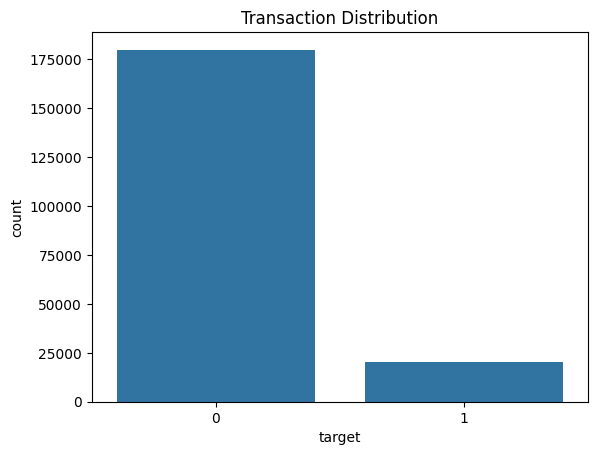

In [10]:
# ============================================
# TARGET DISTRIBUTION
# ============================================

sns.countplot(x=df['target'])

plt.title("Transaction Distribution")

plt.show()

In [11]:
# ============================================
# FEATURES AND TARGET
# ============================================

X = df.drop(
    ['ID_code', 'target'],
    axis=1
)

y = df['target']

In [12]:
# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [13]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (160000, 200)
Testing Shape : (40000, 200)


In [14]:
# ============================================
# LOGISTIC REGRESSION
# ============================================

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Completed")

Logistic Regression Completed


In [15]:
# ============================================
# DECISION TREE
# ============================================

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Completed")

Decision Tree Completed


In [16]:
# ============================================
# RANDOM FOREST
# ============================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Completed")

Random Forest Completed


In [17]:
# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_model(
    y_test,
    pred,
    model_name
):

    accuracy = accuracy_score(
        y_test,
        pred
    )

    print("\n================================")

    print(model_name)

    print("================================")

    print("Accuracy :", accuracy)

    print("\nConfusion Matrix")

    print(confusion_matrix(
        y_test,
        pred
    ))

    print("\nClassification Report")

    print(classification_report(
        y_test,
        pred
    ))

In [18]:
# ============================================
# MODEL EVALUATION
# ============================================

evaluate_model(
    y_test,
    lr_pred,
    "Logistic Regression"
)

evaluate_model(
    y_test,
    dt_pred,
    "Decision Tree"
)

evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)


Logistic Regression
Accuracy : 0.913075

Confusion Matrix
[[35420   483]
 [ 2994  1103]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35903
           1       0.70      0.27      0.39      4097

    accuracy                           0.91     40000
   macro avg       0.81      0.63      0.67     40000
weighted avg       0.90      0.91      0.90     40000


Decision Tree
Accuracy : 0.833325

Confusion Matrix
[[32458  3445]
 [ 3222   875]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     35903
           1       0.20      0.21      0.21      4097

    accuracy                           0.83     40000
   macro avg       0.56      0.56      0.56     40000
weighted avg       0.84      0.83      0.84     40000


Random Forest
Accuracy : 0.8976

Confusion Matrix
[[35903     0]
 [ 4096     1]]

Classification Report
              precisi

In [19]:
# ============================================
# MODEL COMPARISON
# ============================================

comparison = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'Decision Tree',

        'Random Forest'
    ],

    'Accuracy': [

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            dt_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        )
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.913075
1,Decision Tree,0.833325
2,Random Forest,0.897600


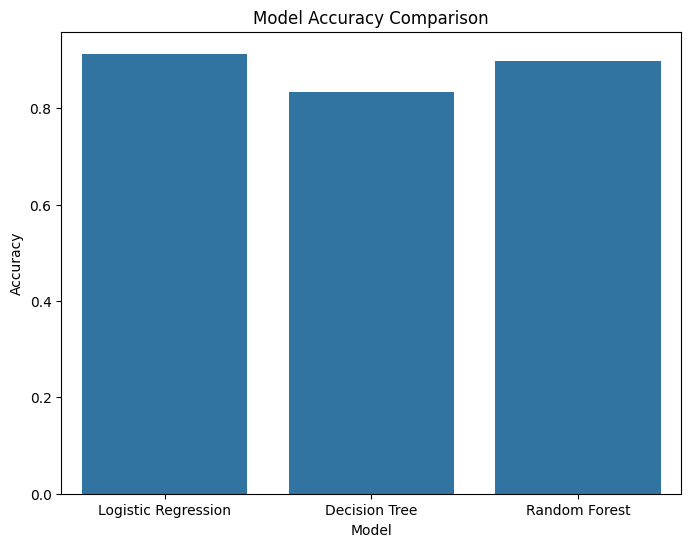

In [20]:
# ============================================
# ACCURACY GRAPH
# ============================================

plt.figure(figsize=(8,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title("Model Accuracy Comparison")

plt.show()

In [21]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
81,var_81,0.012500
12,var_12,0.009893
139,var_139,0.009144
53,var_53,0.008740
146,var_146,0.008331
26,var_26,0.008237
6,var_6,0.008149
110,var_110,0.008073
174,var_174,0.007949
166,var_166,0.007781


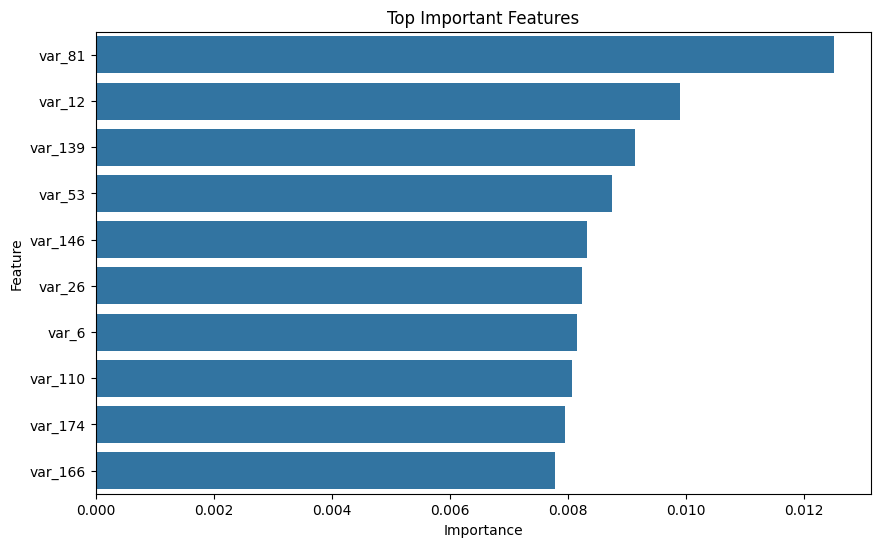

In [22]:
# ============================================
# FEATURE IMPORTANCE GRAPH
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance['Importance'][:10],
    y=importance['Feature'][:10]
)

plt.title("Top Important Features")

plt.show()

In [23]:
# ============================================
# SAVE MODEL
# ============================================

import joblib

joblib.dump(
    rf,
    "customer_transaction_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
# ============================================
# CHALLENGES FACED
# ============================================

print("""

Challenges Faced

1. Anonymous feature names

2. Large dataset handling

3. Feature scaling

4. Model selection

5. Imbalanced target classes

Techniques Used

1. StandardScaler

2. Multiple Model Comparison

3. Random Forest

4. Data Visualization

""")



Challenges Faced

1. Anonymous feature names

2. Large dataset handling

3. Feature scaling

4. Model selection

5. Imbalanced target classes

Techniques Used

1. StandardScaler

2. Multiple Model Comparison

3. Random Forest

4. Data Visualization




In [25]:
# ============================================
# FINAL CONCLUSION
# ============================================

print("""

PROJECT COMPLETED SUCCESSFULLY

Models Used:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Best Model:
Random Forest

This project predicts
future customer transactions
using Machine Learning.

""")



PROJECT COMPLETED SUCCESSFULLY

Models Used:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Best Model:
Random Forest

This project predicts
future customer transactions
using Machine Learning.


